<a href="https://colab.research.google.com/github/Watchman77/AR_Pure_SolarFlares_72h_Dataset/blob/main/XFlareXAI_02_Models_and_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# X-FlareXAI 02: Models and Explainable AI

**Paper title direction:**  
**X-FlareXAI: Comparative Explainable Artificial Intelligence for 48-Hour Solar Flare Forecasting Using SHARP Magnetic and GOES Flare-History Features**

This notebook trains:
1. **Logistic Regression** baseline
2. **XGBoost** classical machine learning model
3. **MLP** deep learning model

Then it generates:
1. **SHAP** explanations
2. **LIME** explanations
3. **Integrated Gradients** explanations

The goal is not only prediction, but explaining which SHARP magnetic and GOES flare-history features drive 48-hour M/X-class flare forecasts.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# 0. Install required packages
# ============================================================

!pip -q install shap lime xgboost

print("Installation complete.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 15.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Installation complete.


In [ ]:
# ============================================================
# 1. Import libraries
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

import shap
from lime.lime_tabular import LimeTabularExplainer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("Libraries loaded.")
print("TensorFlow:", tf.__version__)


Libraries loaded.
TensorFlow: 2.20.0


In [ ]:
# ============================================================
# 2. Configure paths
# ============================================================

BASE_PATH = "/content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT"

DATA_PATH = os.path.join(BASE_PATH, "HMI_AR_2010_2025_ML_READY_48H.csv")

RESULTS_DIR = os.path.join(BASE_PATH, "XFlareXAI_Results")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
TABLES_DIR = os.path.join(RESULTS_DIR, "tables")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("RESULTS_DIR:", RESULTS_DIR)


DATA_PATH: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/HMI_AR_2010_2025_ML_READY_48H.csv
RESULTS_DIR: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results


In [ ]:
# ============================================================
# 3. Load dataset
# ============================================================

df = pd.read_csv(DATA_PATH)

df["T_REC_dt"] = pd.to_datetime(df["T_REC_dt"], errors="coerce")
df = df.dropna(subset=["T_REC_dt", "NOAA_AR", "label_MX_48h"]).copy()
df = df.sort_values("T_REC_dt").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Date range:", df["T_REC_dt"].min(), "to", df["T_REC_dt"].max())

print("Label counts:")
display(df["label_MX_48h"].value_counts().to_frame("count"))

print("Label percentages:")
display((df["label_MX_48h"].value_counts(normalize=True) * 100).to_frame("percent"))

display(df.head())


Dataset shape: (22355, 40)
Date range: 2010-05-01 12:00:00 to 2025-07-16 12:00:00
Label counts:


,count
label_MX_48h,
0,21187
1,1168


Label percentages:


,percent
label_MX_48h,
0,94.775218
1,5.224782


,T_REC,MEANGBZ,HARPNUM,R_VALUE,TOTUSJH,USFLUX,TOTPOT,MEANPOT,AREA_ACR,NOAA_ARS,...,AREA_ACR.1,label_MX_48h,MX_count_last_24h,MX_count_last_48h,C_count_last_24h,C_count_last_48h,max_flare_flux_last_48h,mean_flare_flux_last_48h,time_since_last_MX_hours,flare_activity_index_48h
0,2010.05.01_12:00:00_TAI,135.426,2,0.000,108.818,1.230051e+21,7.219153e+21,2577.490,102.988136,11064,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,9999.0,0.0
1,2010.05.01_12:00:00_TAI,82.596,1,2.960,263.431,5.785536e+21,1.720008e+22,1496.756,66.219543,11067,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,9999.0,0.0
2,2010.05.01_12:00:00_TAI,128.109,6,0.000,41.505,6.926417e+20,2.407468e+21,1488.334,67.645287,11065,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,9999.0,0.0
3,2010.05.02_12:00:00_TAI,129.025,2,0.000,42.533,5.602466e+20,1.781755e+21,1360.688,82.495461,11064,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,9999.0,0.0
4,2010.05.02_12:00:00_TAI,82.971,1,3.173,486.936,1.024649e+22,3.510334e+22,1719.177,203.945465,11067,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,9999.0,0.0


In [ ]:
# ============================================================
# 4. Select modelling features
# ============================================================

sharp_features = [
    "MEANGBZ", "MEANGAM", "MEANGBT", "MEANGBH",
    "MEANJZD", "TOTUSJZ", "MEANALP", "MEANJZH",
    "ABSNJZH", "SAVNCPP", "MEANSHR", "SHRGT45",
    "R_VALUE", "USFLUX", "TOTPOT", "TOTUSJH"
]

goes_features = [
    "MX_count_last_24h",
    "MX_count_last_48h",
    "C_count_last_24h",
    "C_count_last_48h",
    "max_flare_flux_last_48h",
    "mean_flare_flux_last_48h",
    "time_since_last_MX_hours",
    "flare_activity_index_48h"
]

target_col = "label_MX_48h"
feature_cols = sharp_features + goes_features

missing = [c for c in feature_cols + [target_col] if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

model_df = df[["T_REC_dt", "NOAA_AR"] + feature_cols + [target_col]].copy()

# 9999 means no recent M/X flare. Cap it for modelling stability.
model_df["time_since_last_MX_hours"] = model_df["time_since_last_MX_hours"].replace(9999, 72)

for c in feature_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df[feature_cols] = model_df[feature_cols].fillna(model_df[feature_cols].median())

print("Modelling dataset:", model_df.shape)
print("Number of features:", len(feature_cols))
display(model_df.head())


Modelling dataset: (22355, 27)
Number of features: 24


,T_REC_dt,NOAA_AR,MEANGBZ,MEANGAM,MEANGBT,MEANGBH,MEANJZD,TOTUSJZ,MEANALP,MEANJZH,...,TOTUSJH,MX_count_last_24h,MX_count_last_48h,C_count_last_24h,C_count_last_48h,max_flare_flux_last_48h,mean_flare_flux_last_48h,time_since_last_MX_hours,flare_activity_index_48h,label_MX_48h
0,2010-05-01 12:00:00,11064,135.426,34.823,136.321,66.673,0.757142,2.411247e+12,-0.011185,-0.003109,...,108.818,0.0,0.0,0.0,0.0,0.0,0.0,72.0,0.0,0
1,2010-05-01 12:00:00,11067,82.596,23.760,75.801,32.039,-0.202332,5.041179e+12,-0.003394,-0.001074,...,263.431,0.0,0.0,0.0,0.0,0.0,0.0,72.0,0.0,0
2,2010-05-01 12:00:00,11065,128.109,29.002,129.000,49.164,0.375635,1.021202e+12,-0.007351,-0.001561,...,41.505,0.0,0.0,0.0,0.0,0.0,0.0,72.0,0.0,0
3,2010-05-02 12:00:00,11064,129.025,29.608,127.948,56.867,1.981149,1.018732e+12,-0.025063,-0.005277,...,42.533,0.0,0.0,0.0,0.0,0.0,0.0,72.0,0.0,0
4,2010-05-02 12:00:00,11067,82.971,26.171,81.016,34.770,-0.223050,9.660283e+12,0.002879,0.000917,...,486.936,0.0,0.0,0.0,0.0,0.0,0.0,72.0,0.0,0


In [ ]:
# ============================================================
# 5. Chronological split
# ============================================================

# Train: 2010-2018
# Validation: 2019-2020
# Test: 2021-2025

train_df = model_df[model_df["T_REC_dt"].dt.year <= 2018].copy()
val_df = model_df[(model_df["T_REC_dt"].dt.year >= 2019) & (model_df["T_REC_dt"].dt.year <= 2020)].copy()
test_df = model_df[model_df["T_REC_dt"].dt.year >= 2021].copy()

print("Train:", train_df.shape, train_df[target_col].value_counts().to_dict())
print("Val:  ", val_df.shape, val_df[target_col].value_counts().to_dict())
print("Test: ", test_df.shape, test_df[target_col].value_counts().to_dict())

X_train = train_df[feature_cols].values
y_train = train_df[target_col].astype(int).values

X_val = val_df[feature_cols].values
y_val = val_df[target_col].astype(int).values

X_test = test_df[feature_cols].values
y_test = test_df[target_col].astype(int).values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Chronological split ready.")


Train: (12330, 27) {0: 11903, 1: 427}
Val:   (474, 27) {0: 472, 1: 2}
Test:  (9551, 27) {0: 8812, 1: 739}
Chronological split ready.


In [ ]:
# ============================================================
# 6. Evaluation utilities
# ============================================================

def compute_tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    recall = tp / (tp + fn) if (tp + fn) else 0
    specificity = tn / (tn + fp) if (tn + fp) else 0
    tss = recall + specificity - 1

    numerator = 2 * ((tp * tn) - (fp * fn))
    denominator = ((tp + fn) * (fn + tn)) + ((tp + fp) * (fp + tn))
    hss = numerator / denominator if denominator else 0

    return tss, hss, tn, fp, fn, tp


def find_best_threshold_by_tss(y_true, y_prob):
    thresholds = np.linspace(0.01, 0.99, 99)
    best = {"threshold": 0.5, "tss": -999}

    for thr in thresholds:
        pred = (y_prob >= thr).astype(int)
        tss, hss, tn, fp, fn, tp = compute_tss_hss(y_true, pred)

        if tss > best["tss"]:
            best = {
                "threshold": float(thr),
                "tss": float(tss),
                "hss": float(hss),
                "tn": int(tn),
                "fp": int(fp),
                "fn": int(fn),
                "tp": int(tp)
            }

    return best


def evaluate_model(name, y_val, val_prob, y_test, test_prob):
    best = find_best_threshold_by_tss(y_val, val_prob)
    thr = best["threshold"]

    test_pred = (test_prob >= thr).astype(int)
    tss, hss, tn, fp, fn, tp = compute_tss_hss(y_test, test_pred)

    result = {
        "Model": name,
        "Threshold": thr,
        "Val_TSS": best["tss"],
        "Test_TSS": tss,
        "HSS": hss,
        "ROC_AUC": roc_auc_score(y_test, test_prob),
        "PR_AUC": average_precision_score(y_test, test_prob),
        "Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred, zero_division=0),
        "Recall": recall_score(y_test, test_pred, zero_division=0),
        "F1": f1_score(y_test, test_pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    return result, test_pred


In [ ]:
# ============================================================
# 7. Logistic Regression baseline
# ============================================================

log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

log_val_prob = log_reg.predict_proba(X_val_scaled)[:, 1]
log_test_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

log_results, log_test_pred = evaluate_model(
    "Logistic Regression",
    y_val, log_val_prob,
    y_test, log_test_prob
)

log_results


{'Model': 'Logistic Regression',
 'Threshold': 0.48000000000000004,
 'Val_TSS': 0.9343220338983049,
 'Test_TSS': np.float64(0.5877043974356533),
 'HSS': np.float64(0.2658615688639788),
 'ROC_AUC': np.float64(0.8767964339438716),
 'PR_AUC': np.float64(0.43873088475338956),
 'Accuracy': 0.7682965134540886,
 'Precision': 0.2262258543833581,
 'Recall': 0.8240866035182679,
 'F1': 0.3549985426989216,
 'TN': np.int64(6729),
 'FP': np.int64(2083),
 'FN': np.int64(130),
 'TP': np.int64(609)}

In [ ]:
# ============================================================
# 8. XGBoost model
# ============================================================

neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]
xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_results, xgb_test_pred = evaluate_model(
    "XGBoost",
    y_val, xgb_val_prob,
    y_test, xgb_test_prob
)

xgb_results


scale_pos_weight: 27.875878220140514


{'Model': 'XGBoost',
 'Threshold': 0.29000000000000004,
 'Val_TSS': 0.9046610169491527,
 'Test_TSS': np.float64(0.5395005089013198),
 'HSS': np.float64(0.22021981902776275),
 'ROC_AUC': np.float64(0.8699023873829328),
 'PR_AUC': np.float64(0.5012628200654996),
 'Accuracy': 0.7272536907130144,
 'Precision': 0.1968810916179337,
 'Recall': 0.8200270635994588,
 'F1': 0.3175268535499083,
 'TN': np.int64(6340),
 'FP': np.int64(2472),
 'FN': np.int64(133),
 'TP': np.int64(606)}

In [ ]:
# ============================================================
# 9. MLP deep learning model
# ============================================================

tf.keras.utils.set_random_seed(42)

mlp_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.30),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.30),

    Dense(32, activation="relu"),
    Dropout(0.20),

    Dense(1, activation="sigmoid")
])

mlp_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["AUC"]
)

class_weight = {
    0: 1.0,
    1: float(scale_pos_weight)
}

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

mlp_val_prob = mlp_model.predict(X_val_scaled).ravel()
mlp_test_prob = mlp_model.predict(X_test_scaled).ravel()

mlp_results, mlp_test_pred = evaluate_model(
    "MLP",
    y_val, mlp_val_prob,
    y_test, mlp_test_prob
)

mlp_results


Epoch 1/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - AUC: 0.8325 - loss: 1.0285 - val_AUC: 0.8745 - val_loss: 0.2608
Epoch 2/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - AUC: 0.8752 - loss: 0.8665 - val_AUC: 0.9131 - val_loss: 0.2259
Epoch 3/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.8752 - loss: 0.8742 - val_AUC: 0.9243 - val_loss: 0.2400
Epoch 4/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - AUC: 0.8903 - loss: 0.8022 - val_AUC: 0.9327 - val_loss: 0.2398
Epoch 5/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.8943 - loss: 0.8022 - val_AUC: 0.9190 - val_loss: 0.2377
Epoch 6/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8967 - loss: 0.7845 - val_AUC: 0.9301 - val_loss: 0.2252
Epoch 7/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8973 - loss: 0.7840 - val_AUC: 0.9354 - val_loss: 0.2292
Epoch 8/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9025 - loss: 0.7642 - val_AUC: 0.9412 - val_loss: 0.2052
Epoch 9/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4

{'Model': 'MLP',
 'Threshold': 0.59,
 'Val_TSS': 0.9639830508474576,
 'Test_TSS': np.float64(0.5559882052828686),
 'HSS': np.float64(0.3280454910487552),
 'ROC_AUC': np.float64(0.8635223096564717),
 'PR_AUC': np.float64(0.4866458741270859),
 'Accuracy': 0.8373992252120197,
 'Precision': 0.28118279569892474,
 'Recall': 0.7077131258457375,
 'F1': 0.4024624855713736,
 'TN': np.int64(7475),
 'FP': np.int64(1337),
 'FN': np.int64(216),
 'TP': np.int64(523)}

In [ ]:
# ============================================================
# 10. Results table
# ============================================================

results_df = pd.DataFrame([log_results, xgb_results, mlp_results])
results_df = results_df.sort_values("Test_TSS", ascending=False).reset_index(drop=True)

display(results_df)

results_path = os.path.join(TABLES_DIR, "xflarexai_model_results.csv")
results_df.to_csv(results_path, index=False)

print("Saved:", results_path)


,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,Logistic Regression,0.48,0.934322,0.587704,0.265862,0.876796,0.438731,0.768297,0.226226,0.824087,0.354999,6729,2083,130,609
1,MLP,0.59,0.963983,0.555988,0.328045,0.863522,0.486646,0.837399,0.281183,0.707713,0.402462,7475,1337,216,523
2,XGBoost,0.29,0.904661,0.539501,0.220220,0.869902,0.501263,0.727254,0.196881,0.820027,0.317527,6340,2472,133,606


Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/tables/xflarexai_model_results.csv


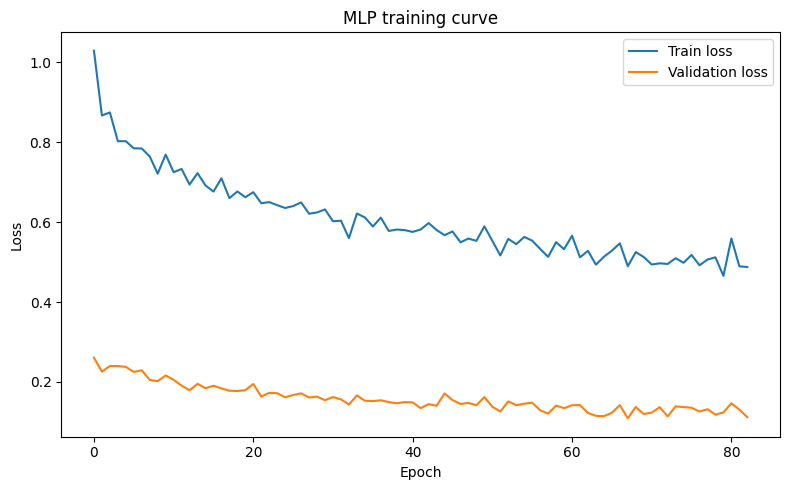

Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/mlp_training_curve.png


In [ ]:
# ============================================================
# 11. Plot MLP training curve
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP training curve")
plt.legend()
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "mlp_training_curve.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


# Explainability section

The next cells generate explanations using a manageable subset of the test set to avoid very long runtimes.


In [ ]:
# ============================================================
# 12. Prepare explanation sample
# ============================================================

EXPLAIN_N = min(500, len(X_test))

rng = np.random.default_rng(42)
explain_idx = rng.choice(len(X_test), size=EXPLAIN_N, replace=False)

X_explain = X_test[explain_idx]
X_explain_scaled = X_test_scaled[explain_idx]
y_explain = y_test[explain_idx]

X_explain_df = pd.DataFrame(X_explain, columns=feature_cols)
X_explain_scaled_df = pd.DataFrame(X_explain_scaled, columns=feature_cols)

print("Explanation sample:", X_explain_df.shape)
print("Positive examples:", int(y_explain.sum()))


Explanation sample: (500, 24)
Positive examples: 43


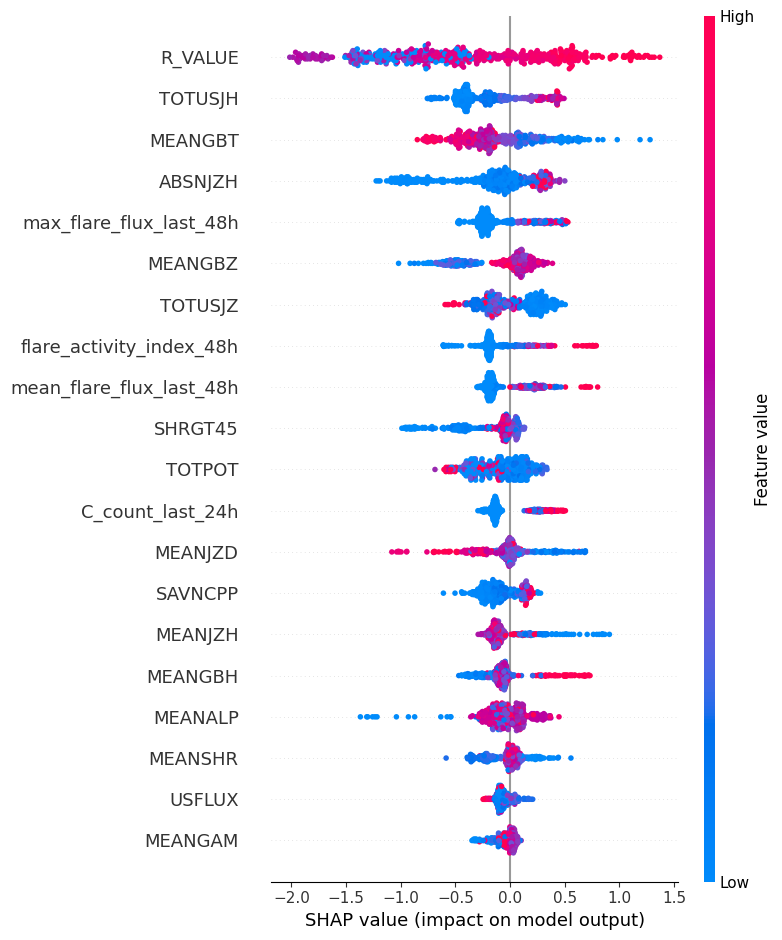

Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/shap_summary_xgboost.png


In [ ]:
# ============================================================
# 13. SHAP summary for XGBoost
# ============================================================

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_explain_df)

shap.summary_plot(
    xgb_shap_values,
    X_explain_df,
    feature_names=feature_cols,
    show=False
)

fig_path = os.path.join(FIGURES_DIR, "shap_summary_xgboost.png")
plt.tight_layout()
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


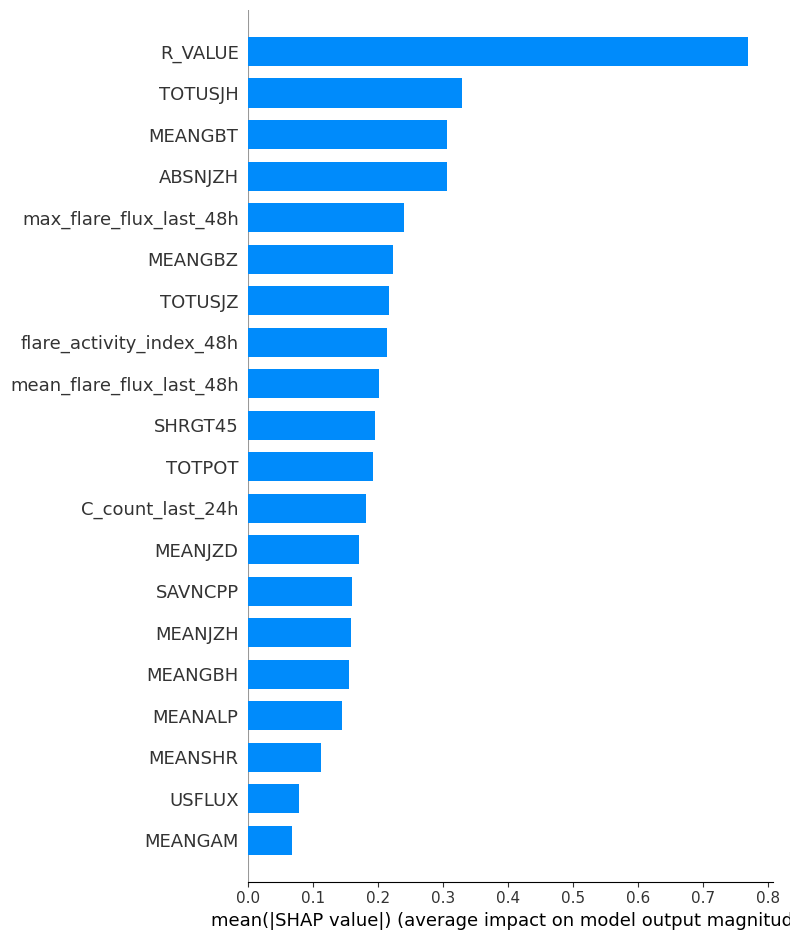

Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/shap_bar_xgboost.png


In [ ]:
# ============================================================
# 14. SHAP bar plot for XGBoost
# ============================================================

shap.summary_plot(
    xgb_shap_values,
    X_explain_df,
    feature_names=feature_cols,
    plot_type="bar",
    show=False
)

fig_path = os.path.join(FIGURES_DIR, "shap_bar_xgboost.png")
plt.tight_layout()
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [ ]:
# ============================================================
# 15. LIME explanation for XGBoost
# ============================================================

lime_explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_cols,
    class_names=["No M/X flare", "M/X flare"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

positive_test_indices = np.where(y_test == 1)[0]
lime_idx = int(positive_test_indices[0]) if len(positive_test_indices) > 0 else 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test[lime_idx],
    predict_fn=xgb_model.predict_proba,
    num_features=10
)

print("LIME explanation for test index:", lime_idx)
display(lime_exp.as_list())

lime_path = os.path.join(FIGURES_DIR, "lime_xgboost_example.html")
lime_exp.save_to_file(lime_path)

print("Saved:", lime_path)


LIME explanation for test index: 148


[('R_VALUE > 3.91', 0.18547223973875593),
 ('ABSNJZH > 75.10', 0.06595736603730169),
 ('7201677000000.00 < TOTUSJZ <= 17017797500000.00', -0.05831646002782875),
 ('MEANJZD <= -0.14', 0.05219851388179843),
 ('106.94 < MEANGBZ <= 123.97', 0.04102138016810289),
 ('flare_activity_index_48h > 0.00', 0.04039629794961619),
 ('MEANALP <= -0.01', -0.036582039171931736),
 ('104.86 < MEANGBT <= 123.43', -0.03624429540513901),
 ('MEANJZH <= -0.00', 0.03510272066504288),
 ('C_count_last_24h <= 0.00', -0.02733692601381268)]

Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/lime_xgboost_example.html


In [ ]:
# ============================================================
# 16. Integrated Gradients for MLP
# ============================================================

def integrated_gradients(model, input_sample, baseline=None, steps=80):
    input_sample = tf.convert_to_tensor(input_sample.reshape(1, -1), dtype=tf.float32)

    if baseline is None:
        baseline = tf.zeros_like(input_sample)
    else:
        baseline = tf.convert_to_tensor(baseline.reshape(1, -1), dtype=tf.float32)

    alphas = tf.linspace(0.0, 1.0, steps)
    total_grads = tf.zeros_like(input_sample)

    for alpha in alphas:
        interpolated = baseline + alpha * (input_sample - baseline)
        with tf.GradientTape() as tape:
            tape.watch(interpolated)
            pred = model(interpolated)
        grads = tape.gradient(pred, interpolated)
        total_grads += grads

    avg_grads = total_grads / tf.cast(steps, tf.float32)
    integrated_grads = (input_sample - baseline) * avg_grads

    return integrated_grads.numpy().flatten()


ig_idx = lime_idx

ig_values = integrated_gradients(
    mlp_model,
    X_test_scaled[ig_idx],
    baseline=np.zeros(X_test_scaled.shape[1]),
    steps=80
)

ig_df = pd.DataFrame({
    "feature": feature_cols,
    "integrated_gradient": ig_values,
    "abs_ig": np.abs(ig_values)
}).sort_values("abs_ig", ascending=False)

display(ig_df.head(15))

ig_path = os.path.join(TABLES_DIR, "integrated_gradients_example.csv")
ig_df.to_csv(ig_path, index=False)

print("Saved:", ig_path)


,feature,integrated_gradient,abs_ig
12,R_VALUE,0.104758,0.104758
4,MEANJZD,0.039692,0.039692
0,MEANGBZ,0.039427,0.039427
2,MEANGBT,-0.031656,0.031656
7,MEANJZH,0.031617,0.031617
6,MEANALP,-0.020784,0.020784
11,SHRGT45,-0.015323,0.015323
1,MEANGAM,-0.011802,0.011802
18,C_count_last_24h,-0.010984,0.010984
19,C_count_last_48h,0.010610,0.010610


Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/tables/integrated_gradients_example.csv


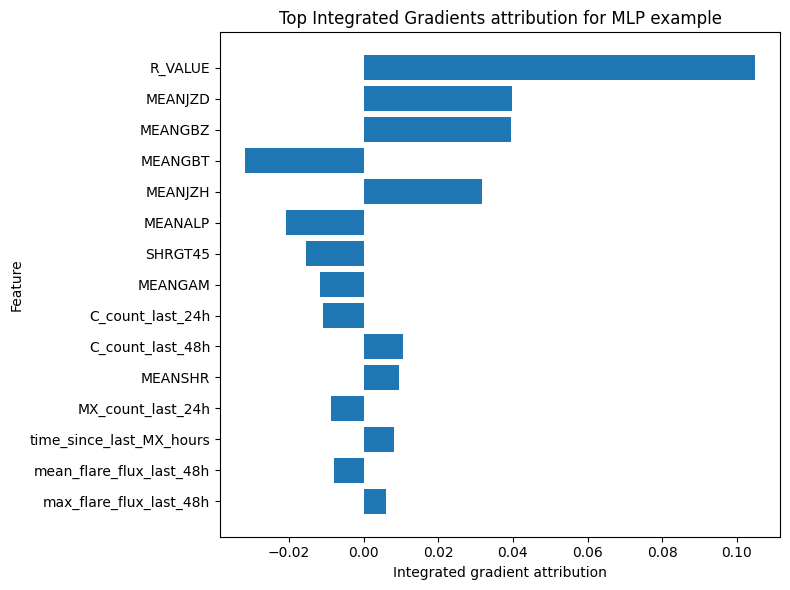

Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/integrated_gradients_mlp_example.png


In [ ]:
# ============================================================
# 17. Plot Integrated Gradients
# ============================================================

top_ig = ig_df.head(15).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_ig["feature"], top_ig["integrated_gradient"])
plt.xlabel("Integrated gradient attribution")
plt.ylabel("Feature")
plt.title("Top Integrated Gradients attribution for MLP example")
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "integrated_gradients_mlp_example.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [ ]:
# ============================================================
# 18. Save predictions
# ============================================================

predictions_df = test_df[["T_REC_dt", "NOAA_AR", target_col]].copy()
predictions_df["logreg_prob"] = log_test_prob
predictions_df["xgboost_prob"] = xgb_test_prob
predictions_df["mlp_prob"] = mlp_test_prob
predictions_df["xgboost_pred"] = xgb_test_pred
predictions_df["mlp_pred"] = mlp_test_pred

pred_path = os.path.join(TABLES_DIR, "test_predictions.csv")
predictions_df.to_csv(pred_path, index=False)

print("Saved:", pred_path)
display(predictions_df.head())


Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/tables/test_predictions.csv


,T_REC_dt,NOAA_AR,label_MX_48h,logreg_prob,xgboost_prob,mlp_prob,xgboost_pred,mlp_pred
12804,2021-01-01 12:00:00,12795,0,0.090802,0.010177,0.005792,0,0
12805,2021-01-01 12:00:00,12794,0,0.257152,0.199381,0.093489,0,0
12806,2021-01-02 12:00:00,12794,0,0.300640,0.148636,0.052777,0,0
12807,2021-01-02 12:00:00,12795,0,0.093668,0.007655,0.004679,0,0
12808,2021-01-03 12:00:00,12795,0,0.135446,0.093151,0.000376,0,0


# After this notebook

Send me:
1. The results table
2. The SHAP top features
3. The LIME explanation list
4. The Integrated Gradients table

Then we will write the Results and Discussion sections of the paper.


In [ ]:
from itertools import product
from xgboost import XGBClassifier
import pandas as pd

param_grid = {
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.05],
    "n_estimators": [300, 500],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}

tuning_results = []

for md, lr, ne in product(
    param_grid["max_depth"],
    param_grid["learning_rate"],
    param_grid["n_estimators"]
):

    print(f"Testing: depth={md}, lr={lr}, estimators={ne}")

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        max_depth=md,
        learning_rate=lr,
        n_estimators=ne,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    val_probs = model.predict_proba(X_val)[:, 1]
    test_probs = model.predict_proba(X_test)[:, 1]

    best = find_best_threshold_by_tss(y_val, val_probs)
    thr = best["threshold"]

    test_pred = (test_probs >= thr).astype(int)
    test_tss, test_hss, tn, fp, fn, tp = compute_tss_hss(y_test, test_pred)

    tuning_results.append({
        "max_depth": md,
        "learning_rate": lr,
        "n_estimators": ne,
        "threshold": thr,
        "val_tss": best["tss"],
        "test_tss": test_tss,
        "test_hss": test_hss,
        "roc_auc": roc_auc_score(y_test, test_probs),
        "pr_auc": average_precision_score(y_test, test_probs),
        "precision": precision_score(y_test, test_pred, zero_division=0),
        "recall": recall_score(y_test, test_pred, zero_division=0),
        "f1": f1_score(y_test, test_pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df.sort_values("test_tss", ascending=False).head(10))

Testing: depth=2, lr=0.01, estimators=300
Testing: depth=2, lr=0.01, estimators=500
Testing: depth=2, lr=0.03, estimators=300
Testing: depth=2, lr=0.03, estimators=500
Testing: depth=2, lr=0.05, estimators=300
Testing: depth=2, lr=0.05, estimators=500
Testing: depth=3, lr=0.01, estimators=300
Testing: depth=3, lr=0.01, estimators=500
Testing: depth=3, lr=0.03, estimators=300
Testing: depth=3, lr=0.03, estimators=500
Testing: depth=3, lr=0.05, estimators=300
Testing: depth=3, lr=0.05, estimators=500
Testing: depth=4, lr=0.01, estimators=300
Testing: depth=4, lr=0.01, estimators=500
Testing: depth=4, lr=0.03, estimators=300
Testing: depth=4, lr=0.03, estimators=500
Testing: depth=4, lr=0.05, estimators=300
Testing: depth=4, lr=0.05, estimators=500


,max_depth,learning_rate,n_estimators,threshold,val_tss,test_tss,test_hss,roc_auc,pr_auc,precision,recall,f1,TN,FP,FN,TP
3,2,0.03,500,0.45,0.913136,0.581097,0.255912,0.875370,0.509133,0.219433,0.828146,0.346939,6635,2177,127,612
5,2,0.05,500,0.43,0.919492,0.574128,0.268219,0.872005,0.502028,0.229159,0.799729,0.356239,6824,1988,148,591
2,2,0.03,300,0.44,0.894068,0.564774,0.230711,0.877466,0.511939,0.202602,0.843031,0.326691,6360,2452,116,623
4,2,0.05,300,0.40,0.902542,0.559781,0.226152,0.875620,0.504514,0.199744,0.843031,0.322965,6316,2496,116,623
9,3,0.03,500,0.35,0.913136,0.557821,0.253838,0.871210,0.507737,0.219768,0.794317,0.344282,6728,2084,152,587
13,4,0.01,500,0.33,0.904661,0.555625,0.226058,0.876623,0.512874,0.199935,0.836265,0.322715,6339,2473,121,618
12,4,0.01,300,0.36,0.902542,0.555582,0.222395,0.877047,0.506440,0.197402,0.843031,0.319897,6279,2533,116,623
11,3,0.05,500,0.27,0.915254,0.552687,0.257605,0.864993,0.495941,0.223038,0.780785,0.346963,6802,2010,162,577
8,3,0.03,300,0.38,0.908898,0.552140,0.235883,0.873636,0.509095,0.207099,0.813261,0.330129,6511,2301,138,601
10,3,0.05,300,0.32,0.913136,0.550044,0.239555,0.870093,0.503003,0.209894,0.803789,0.332866,6576,2236,145,594


In [ ]:
from sklearn.linear_model import LogisticRegression
from itertools import product
import pandas as pd

lr_results = []

C_values = [0.01, 0.1, 1, 5, 10]
penalties = ["l1", "l2"]

for C, penalty in product(C_values, penalties):

    # liblinear supports both l1 and l2
    solver = "liblinear"

    print(f"Testing C={C}, penalty={penalty}")

    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )

    model.fit(X_train, y_train)

    val_probs = model.predict_proba(X_val)[:, 1]
    test_probs = model.predict_proba(X_test)[:, 1]

    best = find_best_threshold_by_tss(y_val, val_probs)

    thr = best["threshold"]

    test_pred = (test_probs >= thr).astype(int)

    test_tss, test_hss, tn, fp, fn, tp = compute_tss_hss(
        y_test,
        test_pred
    )

    lr_results.append({
        "C": C,
        "penalty": penalty,
        "threshold": thr,
        "val_tss": best["tss"],
        "test_tss": test_tss,
        "test_hss": test_hss,
        "roc_auc": roc_auc_score(y_test, test_probs),
        "pr_auc": average_precision_score(y_test, test_probs),
        "precision": precision_score(y_test, test_pred),
        "recall": recall_score(y_test, test_pred),
        "f1": f1_score(y_test, test_pred),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

lr_df = pd.DataFrame(lr_results)
lr_df = lr_df.sort_values("test_tss", ascending=False)

display(lr_df)

Testing C=0.01, penalty=l1
Testing C=0.01, penalty=l2
Testing C=0.1, penalty=l1
Testing C=0.1, penalty=l2
Testing C=1, penalty=l1
Testing C=1, penalty=l2
Testing C=5, penalty=l1
Testing C=5, penalty=l2
Testing C=10, penalty=l1
Testing C=10, penalty=l2


,C,penalty,threshold,val_tss,test_tss,test_hss,roc_auc,pr_auc,precision,recall,f1,TN,FP,FN,TP
6,5.00,l1,0.50,0.925847,0.600387,0.291283,0.878796,0.458811,0.244390,0.810555,0.375549,6960,1852,140,599
0,0.01,l1,0.47,0.927966,0.599830,0.277653,0.878280,0.465758,0.234010,0.826793,0.364776,6812,2000,128,611
4,1.00,l1,0.49,0.923729,0.599323,0.284437,0.878698,0.458583,0.239208,0.817321,0.370098,6891,1921,135,604
8,10.00,l1,0.49,0.921610,0.599096,0.284162,0.878622,0.458422,0.239019,0.817321,0.369871,6889,1923,135,604
2,0.10,l1,0.49,0.923729,0.595481,0.281950,0.877536,0.453440,0.237663,0.814614,0.367971,6881,1931,137,602
1,0.01,l2,0.59,0.866525,0.478470,0.236617,0.808599,0.288728,0.213987,0.691475,0.326831,6935,1877,228,511
5,1.00,l2,0.59,0.866525,0.478470,0.236617,0.808599,0.288728,0.213987,0.691475,0.326831,6935,1877,228,511
3,0.10,l2,0.59,0.866525,0.478470,0.236617,0.808599,0.288728,0.213987,0.691475,0.326831,6935,1877,228,511
7,5.00,l2,0.59,0.866525,0.478470,0.236617,0.808599,0.288728,0.213987,0.691475,0.326831,6935,1877,228,511
9,10.00,l2,0.59,0.866525,0.478470,0.236617,0.808599,0.288728,0.213987,0.691475,0.326831,6935,1877,228,511


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import pandas as pd
import numpy as np

mlp_results = []

configs = [
    ([64, 32], 0.3, 1e-3),
    ([128, 64], 0.3, 1e-3),
    ([128, 64, 32], 0.3, 1e-3),
    ([128, 64], 0.4, 5e-4),
    ([256, 128, 64], 0.3, 5e-4),
]

for hidden_layers, dropout_rate, lr in configs:

    print("\nTesting:", hidden_layers, dropout_rate, lr)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    model = Sequential()

    model.add(Dense(
        hidden_layers[0],
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation="relu"))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["AUC"]
    )

    es = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=256,
        class_weight=class_weight,
        verbose=0,
        callbacks=[es]
    )

    val_probs = model.predict(X_val_scaled).flatten()
    test_probs = model.predict(X_test_scaled).flatten()

    # Safety clean-up
    val_probs = np.nan_to_num(val_probs, nan=0.0, posinf=1.0, neginf=0.0)
    test_probs = np.nan_to_num(test_probs, nan=0.0, posinf=1.0, neginf=0.0)

    best = find_best_threshold_by_tss(y_val, val_probs)
    thr = best["threshold"]

    test_pred = (test_probs >= thr).astype(int)

    test_tss, test_hss, tn, fp, fn, tp = compute_tss_hss(y_test, test_pred)

    mlp_results.append({
        "layers": str(hidden_layers),
        "dropout": dropout_rate,
        "lr": lr,
        "threshold": thr,
        "val_tss": best["tss"],
        "test_tss": test_tss,
        "test_hss": test_hss,
        "roc_auc": roc_auc_score(y_test, test_probs),
        "pr_auc": average_precision_score(y_test, test_probs),
        "precision": precision_score(y_test, test_pred, zero_division=0),
        "recall": recall_score(y_test, test_pred, zero_division=0),
        "f1": f1_score(y_test, test_pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

mlp_df = pd.DataFrame(mlp_results)
display(mlp_df.sort_values("test_tss", ascending=False))


Testing: [64, 32] 0.3 0.001
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Testing: [128, 64] 0.3 0.001
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Testing: [128, 64, 32] 0.3 0.001
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Testing: [128, 64] 0.4 0.0005
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Testing: [256, 128, 64] 0.3 0.0005
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,layers,dropout,lr,threshold,val_tss,test_tss,test_hss,roc_auc,pr_auc,precision,recall,f1,TN,FP,FN,TP
1,"[128, 64]",0.3,0.0010,0.67,0.959746,0.577288,0.358441,0.869367,0.497724,0.305684,0.713126,0.427933,7615,1197,212,527
3,"[128, 64]",0.4,0.0005,0.75,0.972458,0.565151,0.386945,0.868919,0.504366,0.337382,0.676590,0.450248,7830,982,239,500
0,"[64, 32]",0.3,0.0010,0.69,0.961864,0.561688,0.342559,0.864793,0.492839,0.293619,0.703654,0.414343,7561,1251,219,520
4,"[256, 128, 64]",0.3,0.0005,0.65,0.953390,0.553578,0.340055,0.866979,0.480443,0.292808,0.694181,0.411883,7573,1239,226,513
2,"[128, 64, 32]",0.3,0.0010,0.80,0.980932,0.522308,0.427454,0.858996,0.486673,0.402005,0.596752,0.480392,8156,656,298,441


# Step 1: Generate probabilities from the best models

In [ ]:
# ==========================================================
# BEST LOGISTIC REGRESSION
# ==========================================================

best_lr = LogisticRegression(
    C=5,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

best_lr.fit(X_train, y_train)

lr_val_probs = best_lr.predict_proba(X_val)[:,1]
lr_test_probs = best_lr.predict_proba(X_test)[:,1]


# ==========================================================
# BEST XGBOOST
# ==========================================================

best_xgb = XGBClassifier(
    max_depth=2,
    learning_rate=0.03,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

xgb_val_probs = best_xgb.predict_proba(X_val)[:,1]
xgb_test_probs = best_xgb.predict_proba(X_test)[:,1]


# ==========================================================
# BEST MLP
# ==========================================================

tf.keras.backend.clear_session()

best_mlp = Sequential([
    Dense(128, activation='relu',
          input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

best_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['AUC']
)

es = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

best_mlp.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    verbose=0,
    class_weight=class_weight,
    callbacks=[es]
)

mlp_val_probs = best_mlp.predict(X_val_scaled).flatten()
mlp_test_probs = best_mlp.predict(X_test_scaled).flatten()

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


# Step 2: Create Ensembles

In [ ]:
ensemble_results = []

ensembles = {
    "Simple Average":
        (lr_val_probs + xgb_val_probs + mlp_val_probs)/3,

    "0.4LR+0.4XGB+0.2MLP":
        0.4*lr_val_probs + 0.4*xgb_val_probs + 0.2*mlp_val_probs,

    "0.5LR+0.3XGB+0.2MLP":
        0.5*lr_val_probs + 0.3*xgb_val_probs + 0.2*mlp_val_probs
}


test_ensembles = {
    "Simple Average":
        (lr_test_probs + xgb_test_probs + mlp_test_probs)/3,

    "0.4LR+0.4XGB+0.2MLP":
        0.4*lr_test_probs + 0.4*xgb_test_probs + 0.2*mlp_test_probs,

    "0.5LR+0.3XGB+0.2MLP":
        0.5*lr_test_probs + 0.3*xgb_test_probs + 0.2*mlp_test_probs
}

# Step 3: Evaluate Ensembles

In [ ]:
for name in ensembles.keys():

    val_probs = ensembles[name]
    test_probs = test_ensembles[name]

    best = find_best_threshold_by_tss(y_val, val_probs)

    thr = best["threshold"]

    test_pred = (test_probs >= thr).astype(int)

    test_tss, test_hss, tn, fp, fn, tp = \
        compute_tss_hss(y_test, test_pred)

    ensemble_results.append({
        "Model": name,
        "Threshold": thr,
        "Val_TSS": best["tss"],
        "Test_TSS": test_tss,
        "HSS": test_hss,
        "ROC_AUC": roc_auc_score(y_test, test_probs),
        "PR_AUC": average_precision_score(y_test, test_probs),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1": f1_score(y_test, test_pred),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

ensemble_df = pd.DataFrame(ensemble_results)
ensemble_df = ensemble_df.sort_values(
    "Test_TSS",
    ascending=False
)

display(ensemble_df)

,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Precision,Recall,F1,TN,FP,FN,TP
1,0.4LR+0.4XGB+0.2MLP,0.53,0.942797,0.594945,0.317370,0.883576,0.524946,0.266047,0.774019,0.395985,7234,1578,167,572
4,0.4LR+0.4XGB+0.2MLP,0.53,0.942797,0.594945,0.317370,0.883576,0.524946,0.266047,0.774019,0.395985,7234,1578,167,572
5,0.5LR+0.3XGB+0.2MLP,0.53,0.951271,0.594159,0.317581,0.884118,0.522751,0.266325,0.772666,0.396115,7239,1573,168,571
2,0.5LR+0.3XGB+0.2MLP,0.53,0.951271,0.594159,0.317581,0.884118,0.522751,0.266325,0.772666,0.396115,7239,1573,168,571
0,Simple Average,0.55,0.949153,0.592944,0.340510,0.882205,0.522243,0.286305,0.749662,0.414361,7431,1381,185,554
3,Simple Average,0.55,0.949153,0.592944,0.340510,0.882205,0.522243,0.286305,0.749662,0.414361,7431,1381,185,554


In [ ]:
# ============================================================
# 19. Bootstrap CI for TSS + McNemar Tests
# ============================================================

from sklearn.utils import resample
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Collect final model probabilities and predictions
# ------------------------------------------------------------

final_models = {
    "Tuned_LR": {
        "prob": lr_test_probs,
        "threshold": 0.50
    },
    "Tuned_XGBoost": {
        "prob": xgb_test_probs,
        "threshold": 0.45
    },
    "Tuned_MLP": {
        "prob": mlp_test_probs,
        "threshold": 0.67
    },
    "Simple_Average_Ensemble": {
        "prob": (lr_test_probs + xgb_test_probs + mlp_test_probs) / 3,
        "threshold": 0.53
    }
}

for name in final_models:
    final_models[name]["pred"] = (
        final_models[name]["prob"] >= final_models[name]["threshold"]
    ).astype(int)


# ------------------------------------------------------------
# Bootstrap TSS confidence interval
# ------------------------------------------------------------

def bootstrap_tss_ci(y_true, y_pred, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    tss_scores = []

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    n = len(y_true)

    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)

        # Skip invalid bootstrap samples with one class only
        if len(np.unique(y_true[idx])) < 2:
            continue

        tss, hss, tn, fp, fn, tp = compute_tss_hss(
            y_true[idx],
            y_pred[idx]
        )

        tss_scores.append(tss)

    return {
        "mean": np.mean(tss_scores),
        "ci_low": np.percentile(tss_scores, 2.5),
        "ci_high": np.percentile(tss_scores, 97.5),
        "n_boot_valid": len(tss_scores)
    }


bootstrap_rows = []

for name, item in final_models.items():
    ci = bootstrap_tss_ci(
        y_test,
        item["pred"],
        n_boot=2000,
        seed=42
    )

    bootstrap_rows.append({
        "Model": name,
        "TSS_mean": ci["mean"],
        "TSS_CI_low": ci["ci_low"],
        "TSS_CI_high": ci["ci_high"],
        "n_boot_valid": ci["n_boot_valid"]
    })

bootstrap_df = pd.DataFrame(bootstrap_rows)
display(bootstrap_df)

bootstrap_path = os.path.join(
    TABLES_DIR,
    "bootstrap_tss_ci.csv"
)
bootstrap_df.to_csv(bootstrap_path, index=False)

print("Saved bootstrap CI:", bootstrap_path)


# ------------------------------------------------------------
# McNemar tests
# ------------------------------------------------------------

def run_mcnemar(y_true, pred_a, pred_b, model_a, model_b):
    """
    McNemar test compares whether two classifiers make significantly
    different errors on the same test samples.
    """

    correct_a = pred_a == y_true
    correct_b = pred_b == y_true

    # Contingency table:
    #               Model B correct   Model B wrong
    # Model A correct       both         A only
    # Model A wrong         B only       neither

    both_correct = np.sum(correct_a & correct_b)
    a_only = np.sum(correct_a & ~correct_b)
    b_only = np.sum(~correct_a & correct_b)
    both_wrong = np.sum(~correct_a & ~correct_b)

    table = [[both_correct, a_only],
             [b_only, both_wrong]]

    result = mcnemar(
        table,
        exact=False,
        correction=True
    )

    return {
        "Comparison": f"{model_a} vs {model_b}",
        "b_A_correct_B_wrong": int(a_only),
        "c_A_wrong_B_correct": int(b_only),
        "chi2": float(result.statistic),
        "p_value": float(result.pvalue)
    }


comparisons = [
    ("Tuned_LR", "Tuned_XGBoost"),
    ("Tuned_LR", "Tuned_MLP"),
    ("Tuned_LR", "Simple_Average_Ensemble"),
    ("Tuned_XGBoost", "Tuned_MLP"),
    ("Tuned_XGBoost", "Simple_Average_Ensemble"),
    ("Tuned_MLP", "Simple_Average_Ensemble")
]

mcnemar_rows = []

for a, b in comparisons:
    row = run_mcnemar(
        y_test,
        final_models[a]["pred"],
        final_models[b]["pred"],
        a,
        b
    )
    mcnemar_rows.append(row)

mcnemar_df = pd.DataFrame(mcnemar_rows)
display(mcnemar_df)

mcnemar_path = os.path.join(
    TABLES_DIR,
    "mcnemar_model_comparisons.csv"
)
mcnemar_df.to_csv(mcnemar_path, index=False)

print("Saved McNemar results:", mcnemar_path)

,Model,TSS_mean,TSS_CI_low,TSS_CI_high,n_boot_valid
0,Tuned_LR,0.600337,0.570247,0.628392,2000
1,Tuned_XGBoost,0.580768,0.551237,0.607720,2000
2,Tuned_MLP,0.544330,0.507796,0.576140,2000
3,Simple_Average_Ensemble,0.586531,0.553777,0.617753,2000


Saved bootstrap CI: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/tables/bootstrap_tss_ci.csv


,Comparison,b_A_correct_B_wrong,c_A_wrong_B_correct,chi2,p_value
0,Tuned_LR vs Tuned_XGBoost,706,394,87.928182,6.787469e-21
1,Tuned_LR vs Tuned_MLP,308,1018,379.095777,1.958058e-84
2,Tuned_LR vs Simple_Average_Ensemble,239,556,125.605031,3.751968e-29
3,Tuned_XGBoost vs Tuned_MLP,203,1225,730.000700,8.954628e-161
4,Tuned_XGBoost vs Simple_Average_Ensemble,110,739,464.527680,4.972793e-103
5,Tuned_MLP vs Simple_Average_Ensemble,544,151,221.099281,5.207210e-50


Saved McNemar results: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/tables/mcnemar_model_comparisons.csv


In [ ]:
Cell 1 — Rebuild final tuned models

In [ ]:
# ============================================================
# 20. Rebuild final tuned models for paper-ready XAI
# ============================================================

# Tuned Logistic Regression
best_lr = LogisticRegression(
    C=5,
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

best_lr.fit(X_train_scaled, y_train)

lr_val_probs = best_lr.predict_proba(X_val_scaled)[:, 1]
lr_test_probs = best_lr.predict_proba(X_test_scaled)[:, 1]


# Tuned XGBoost
best_xgb = XGBClassifier(
    max_depth=2,
    learning_rate=0.03,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

xgb_val_probs = best_xgb.predict_proba(X_val)[:, 1]
xgb_test_probs = best_xgb.predict_proba(X_test)[:, 1]

Cell 2 — Logistic Regression coefficient plot

,feature,coefficient,abs_coefficient
2,MEANGBT,-1.917194,1.917194
15,TOTUSJH,1.321109,1.321109
0,MEANGBZ,0.890692,0.890692
11,SHRGT45,-0.866856,0.866856
3,MEANGBH,0.792371,0.792371
10,MEANSHR,0.733325,0.733325
14,TOTPOT,-0.617552,0.617552
12,R_VALUE,0.457819,0.457819
21,mean_flare_flux_last_48h,0.450468,0.450468
5,TOTUSJZ,-0.343744,0.343744


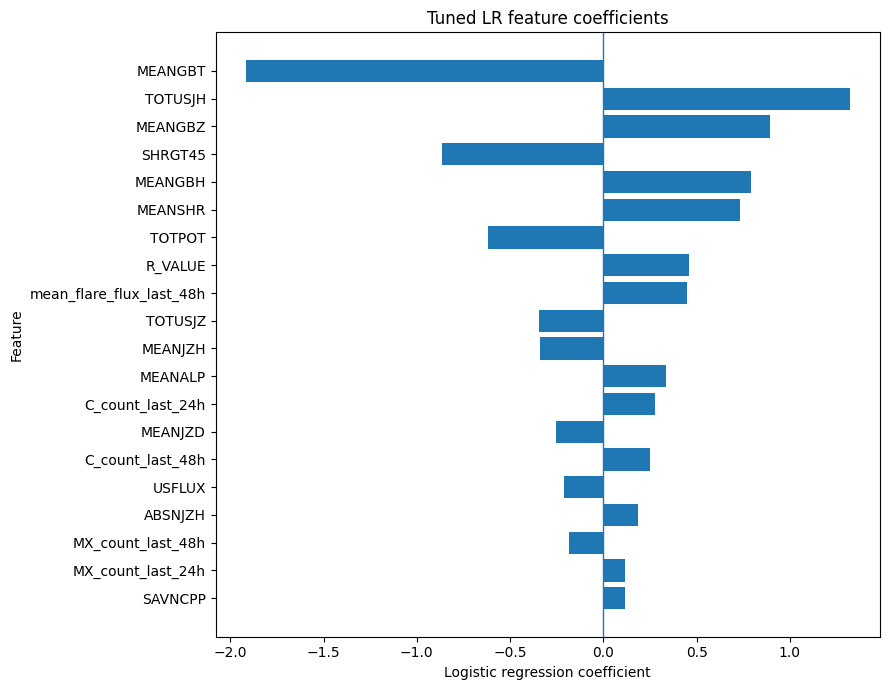

Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/tuned_lr_coefficients.png


In [ ]:
# ============================================================
# 21. Tuned LR coefficient importance
# ============================================================

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": best_lr.coef_[0],
    "abs_coefficient": np.abs(best_lr.coef_[0])
}).sort_values("abs_coefficient", ascending=False)

display(coef_df)

coef_path = os.path.join(TABLES_DIR, "tuned_lr_coefficients.csv")
coef_df.to_csv(coef_path, index=False)

top_coef = coef_df.head(20).iloc[::-1]

plt.figure(figsize=(9, 7))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Logistic regression coefficient")
plt.ylabel("Feature")
plt.title("Tuned LR feature coefficients")
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "tuned_lr_coefficients.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

Cell 3 — Tuned XGBoost SHAP

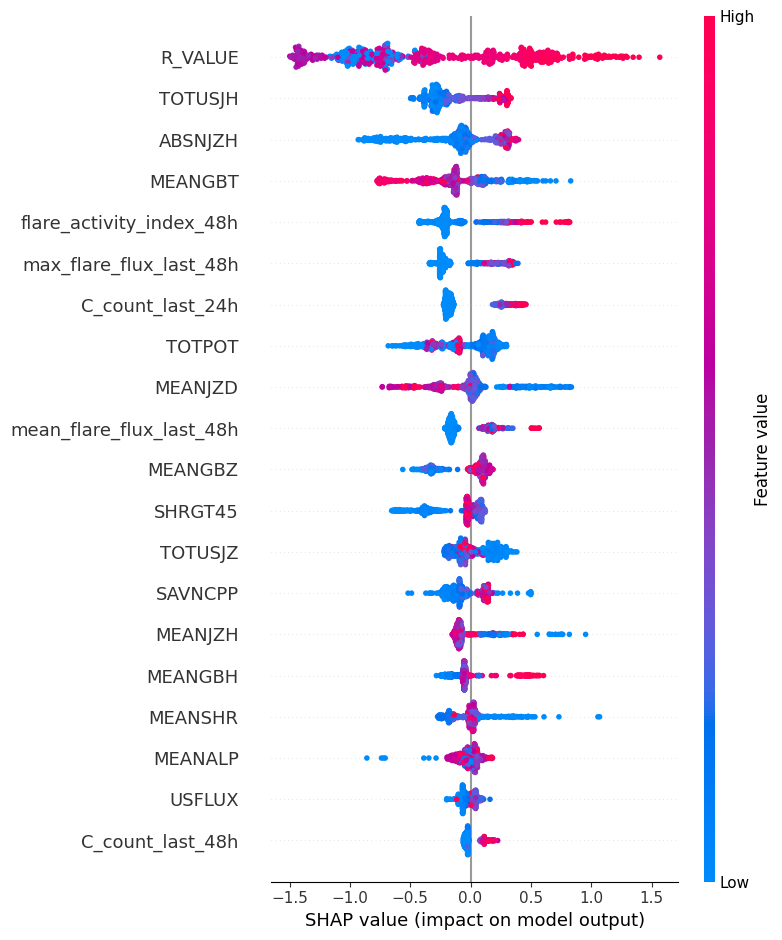

Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/tuned_xgb_shap_beeswarm.png


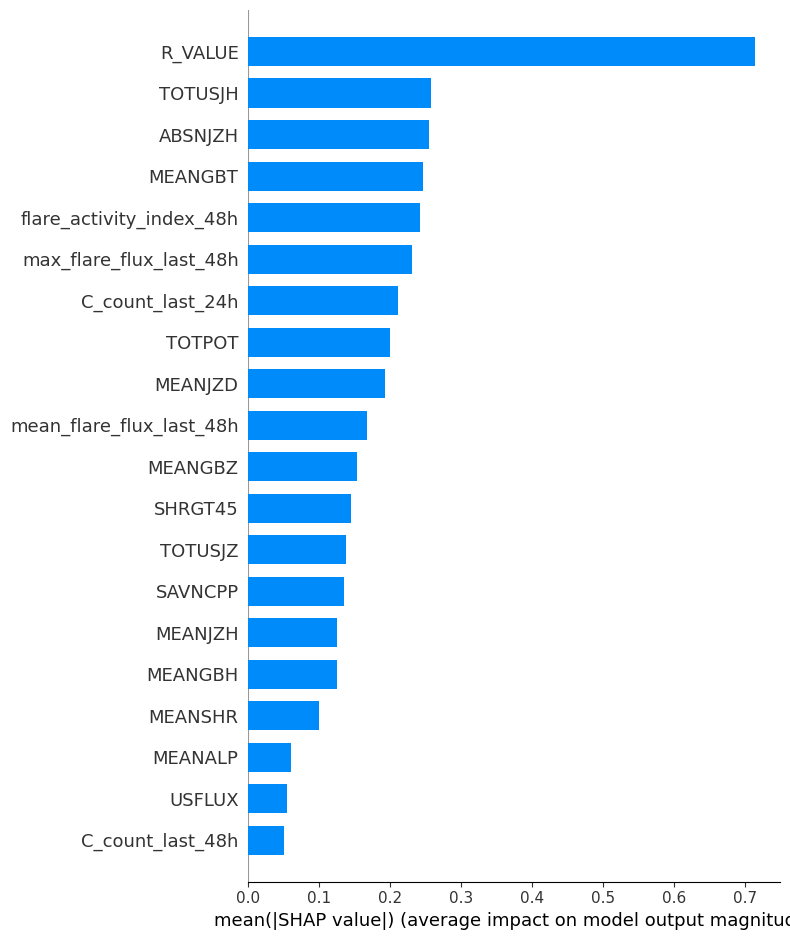

Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/tuned_xgb_shap_bar.png


In [ ]:
# ============================================================
# 22. Tuned XGBoost SHAP explanations
# ============================================================

EXPLAIN_N = min(700, len(X_test))

rng = np.random.default_rng(42)
explain_idx = rng.choice(len(X_test), size=EXPLAIN_N, replace=False)

X_explain = X_test[explain_idx]
X_explain_df = pd.DataFrame(X_explain, columns=feature_cols)

xgb_explainer = shap.TreeExplainer(best_xgb)
xgb_shap_values = xgb_explainer.shap_values(X_explain_df)

# SHAP beeswarm
shap.summary_plot(
    xgb_shap_values,
    X_explain_df,
    feature_names=feature_cols,
    show=False
)

fig_path = os.path.join(FIGURES_DIR, "tuned_xgb_shap_beeswarm.png")
plt.tight_layout()
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


# SHAP bar
shap.summary_plot(
    xgb_shap_values,
    X_explain_df,
    feature_names=feature_cols,
    plot_type="bar",
    show=False
)

fig_path = os.path.join(FIGURES_DIR, "tuned_xgb_shap_bar.png")
plt.tight_layout()
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

Cell 4 — SHAP dependence plots

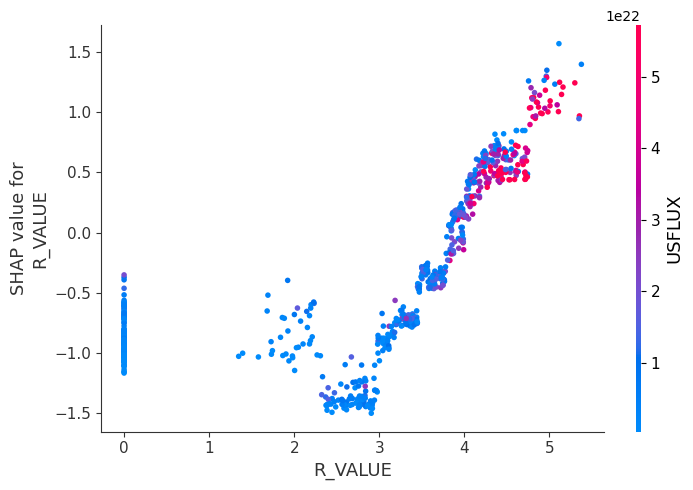

Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/tuned_xgb_shap_dependence_R_VALUE.png


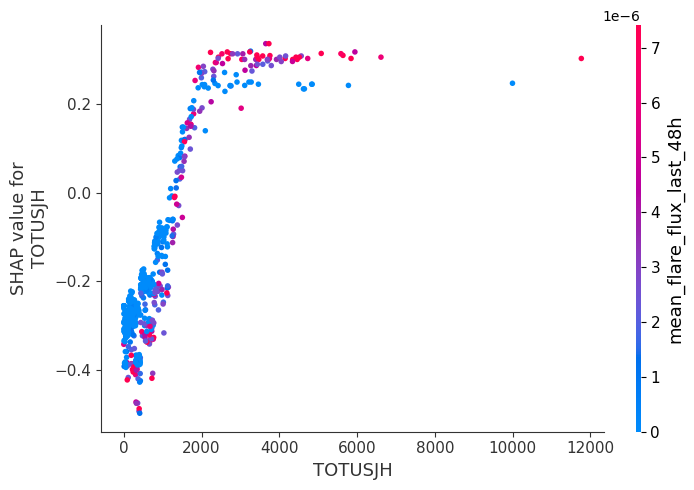

Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/tuned_xgb_shap_dependence_TOTUSJH.png


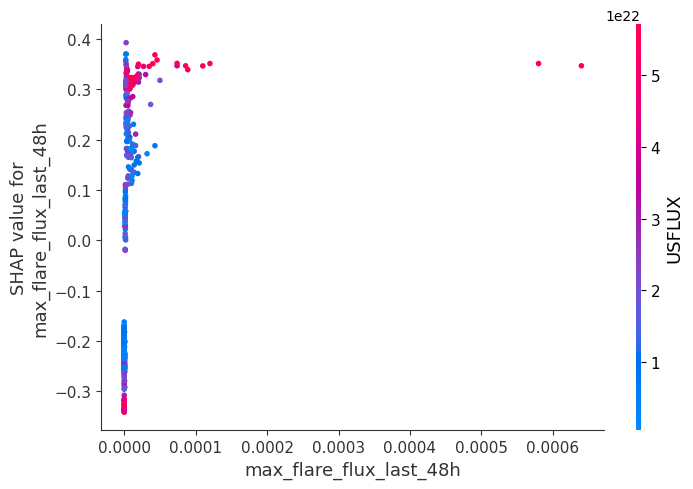

Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/tuned_xgb_shap_dependence_max_flare_flux_last_48h.png


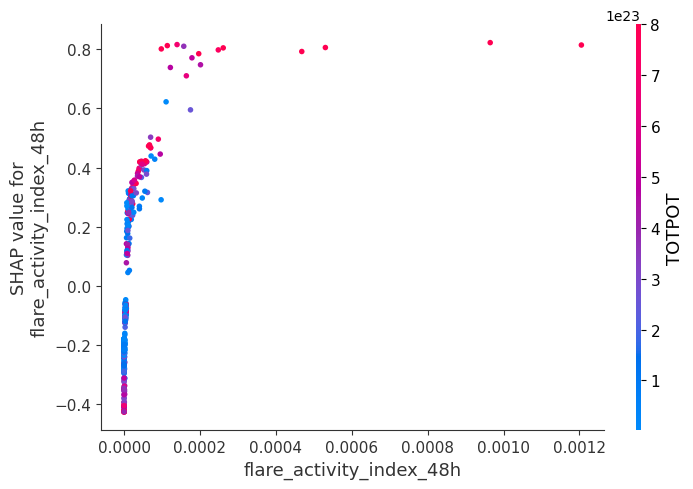

Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/tuned_xgb_shap_dependence_flare_activity_index_48h.png


In [ ]:
# ============================================================
# 23. Tuned XGBoost SHAP dependence plots
# ============================================================

dependence_features = [
    "R_VALUE",
    "TOTUSJH",
    "max_flare_flux_last_48h",
    "flare_activity_index_48h"
]

for feat in dependence_features:
    if feat in feature_cols:
        shap.dependence_plot(
            feat,
            xgb_shap_values,
            X_explain_df,
            feature_names=feature_cols,
            show=False
        )

        fig_path = os.path.join(
            FIGURES_DIR,
            f"tuned_xgb_shap_dependence_{feat}.png"
        )

        plt.tight_layout()
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved:", fig_path)

Cell 5 — Tuned MLP Integrated Gradients

,feature,integrated_gradient,abs_ig
7,MEANJZH,0.248128,0.248128
4,MEANJZD,0.234523,0.234523
12,R_VALUE,0.231681,0.231681
2,MEANGBT,-0.096562,0.096562
6,MEANALP,-0.071752,0.071752
11,SHRGT45,-0.032000,0.032000
18,C_count_last_24h,-0.028869,0.028869
0,MEANGBZ,0.027789,0.027789
3,MEANGBH,0.024871,0.024871
13,USFLUX,0.024193,0.024193


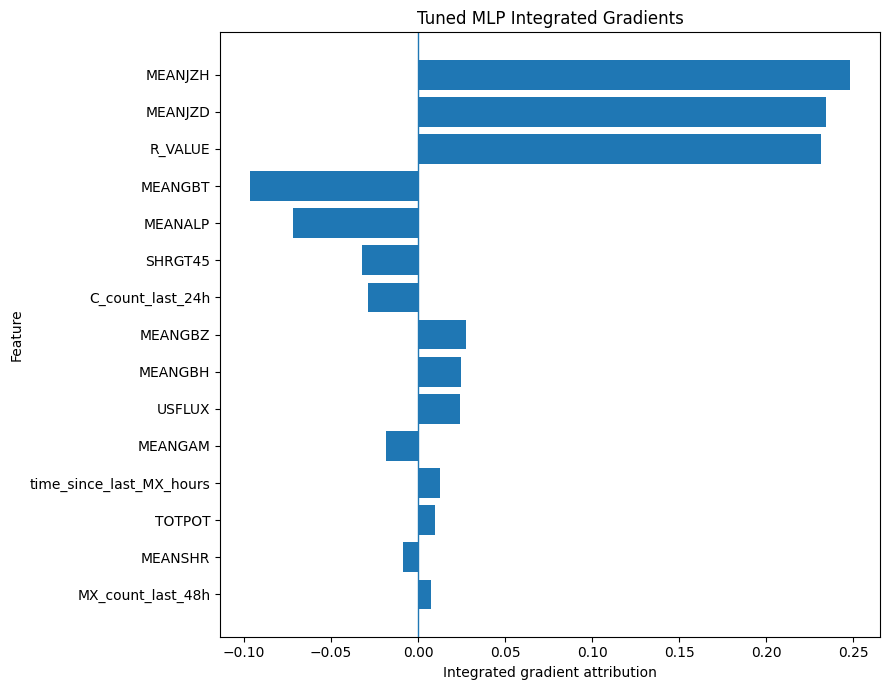

Saved: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/tuned_mlp_integrated_gradients.png


In [ ]:
# ============================================================
# 24. Tuned MLP Integrated Gradients
# ============================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

best_mlp = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

best_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["AUC"]
)

es = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

best_mlp.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[es],
    verbose=0
)


def integrated_gradients(model, input_sample, baseline=None, steps=80):
    input_sample = tf.convert_to_tensor(input_sample.reshape(1, -1), dtype=tf.float32)

    if baseline is None:
        baseline = tf.zeros_like(input_sample)
    else:
        baseline = tf.convert_to_tensor(baseline.reshape(1, -1), dtype=tf.float32)

    alphas = tf.linspace(0.0, 1.0, steps)
    total_grads = tf.zeros_like(input_sample)

    for alpha in alphas:
        interpolated = baseline + alpha * (input_sample - baseline)
        with tf.GradientTape() as tape:
            tape.watch(interpolated)
            pred = model(interpolated)

        grads = tape.gradient(pred, interpolated)
        total_grads += grads

    avg_grads = total_grads / tf.cast(steps, tf.float32)
    integrated_grads = (input_sample - baseline) * avg_grads

    return integrated_grads.numpy().flatten()


positive_test_indices = np.where(y_test == 1)[0]
ig_idx = int(positive_test_indices[0]) if len(positive_test_indices) > 0 else 0

ig_values = integrated_gradients(
    best_mlp,
    X_test_scaled[ig_idx],
    baseline=np.zeros(X_test_scaled.shape[1]),
    steps=80
)

ig_df = pd.DataFrame({
    "feature": feature_cols,
    "integrated_gradient": ig_values,
    "abs_ig": np.abs(ig_values)
}).sort_values("abs_ig", ascending=False)

display(ig_df.head(20))

ig_path = os.path.join(TABLES_DIR, "tuned_mlp_integrated_gradients.csv")
ig_df.to_csv(ig_path, index=False)

top_ig = ig_df.head(15).iloc[::-1]

plt.figure(figsize=(9, 7))
plt.barh(top_ig["feature"], top_ig["integrated_gradient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Integrated gradient attribution")
plt.ylabel("Feature")
plt.title("Tuned MLP Integrated Gradients")
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "tuned_mlp_integrated_gradients.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

Selected test index: 148
True label: 1
XGBoost probability: 0.5450157


[('R_VALUE > 3.91', 0.23130322418349045),
 ('ABSNJZH > 75.10', 0.09445848124432181),
 ('flare_activity_index_48h > 0.00', 0.09047777690933613),
 ('MEANJZD <= -0.14', 0.07804320522959121),
 ('C_count_last_24h <= 0.00', -0.06269927684319193),
 ('7201677000000.00 < TOTUSJZ <= 17017797500000.00', -0.0549653534733852),
 ('44200084999999999442944.00 < TOTPOT <= 163111425000000003768320.00',
  0.052521440171210264),
 ('MEANJZH <= -0.00', 0.04470678926996489),
 ('SAVNCPP > 3850754250000.00', 0.034257297779574127),
 ('106.94 < MEANGBZ <= 123.97', 0.032642554870250896),
 ('0.00 < mean_flare_flux_last_48h <= 0.00', -0.030842056573949866),
 ('104.86 < MEANGBT <= 123.43', -0.025976482517560125)]

Saved LIME HTML: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/tuned_xgb_lime_positive_example.html


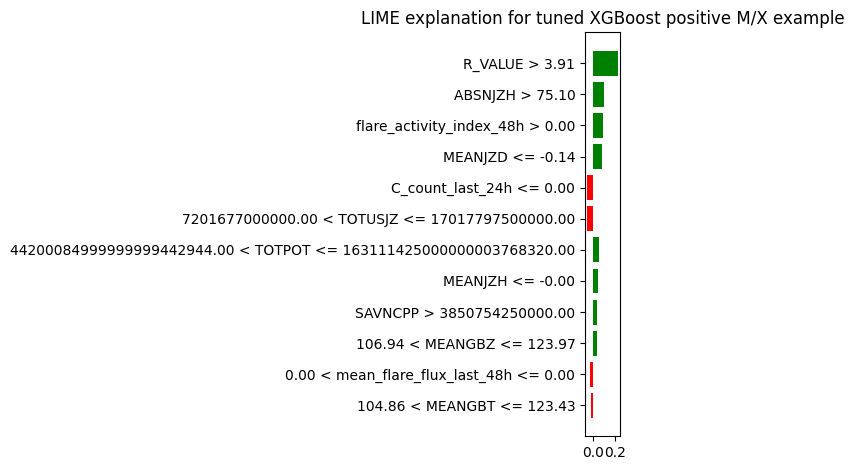

Saved LIME PNG: /content/drive/MyDrive/AR_Stratified/CICCE_BRADFORD_PROJECT/XFlareXAI_Results/figures/tuned_xgb_lime_positive_example.png


In [ ]:
# ============================================================
# 25. LIME local explanation for tuned XGBoost
# ============================================================

from lime.lime_tabular import LimeTabularExplainer

# Create LIME explainer using training data
lime_explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_cols,
    class_names=["No M/X flare", "M/X flare"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Choose one positive M/X example from the test set
positive_test_indices = np.where(y_test == 1)[0]

if len(positive_test_indices) == 0:
    lime_idx = 0
else:
    lime_idx = int(positive_test_indices[0])

print("Selected test index:", lime_idx)
print("True label:", y_test[lime_idx])
print("XGBoost probability:", best_xgb.predict_proba(X_test[lime_idx].reshape(1, -1))[0, 1])

# Generate LIME explanation
lime_exp = lime_explainer.explain_instance(
    data_row=X_test[lime_idx],
    predict_fn=best_xgb.predict_proba,
    num_features=12
)

# Display explanation as list
display(lime_exp.as_list())

# Save LIME explanation as HTML
lime_html_path = os.path.join(
    FIGURES_DIR,
    "tuned_xgb_lime_positive_example.html"
)

lime_exp.save_to_file(lime_html_path)

print("Saved LIME HTML:", lime_html_path)

# Save LIME explanation as PNG figure
fig = lime_exp.as_pyplot_figure()
plt.title("LIME explanation for tuned XGBoost positive M/X example")
plt.tight_layout()

lime_png_path = os.path.join(
    FIGURES_DIR,
    "tuned_xgb_lime_positive_example.png"
)

plt.savefig(lime_png_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved LIME PNG:", lime_png_path)